# Manual validation of the predicted cell types

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 23rd December 2024\
**Last modified date:** 23rd December 2024

This notebook outlines the process of validation of predicted by `scVI - scANVI` pipeline cell type annotations. We will evaluate `scANVI` classificator confidence and also validate the predicted annotation with markers.

Then we will generate multiple plots for the dataset description. 

## Import packages

In [1]:
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
from pywaffle import Waffle
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
import scipy.sparse

## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [4]:
timestamp

'05022025_215607'

## Upload data

In [5]:
adata = sc.read_h5ad('data/gut_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_10012025_100142_raw.h5ad')
adata

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

## Validate confidence score and markers expression

In [ ]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=["C_scANVI", "confidence_score"], ncols=4, color_map = 'magma', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/scANVI_confidence_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ B cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'CD19', 'MS4A1', 'CD79A', 'CD79B', 'CD22'], ncols=3, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/B_cells_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Endothelial cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'PECAM1', 'CDH5', 'VWF', 'CLDN5', 'TEK', 'KDR'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Endothelial_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Epithelial cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1', 'CLDN4'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Epithelial_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Mesenchymal cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'COL1A1', 'COL3A1', 'VIM', 'DCN', 'FAP', 'THY1'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Mesenchymal_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Myeloid cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'CD14', 'CD68', 'CD163', 'CSF1R', 'ITGAM', 'ITGAM', 'CD72', 'CD128', 'FOLR2', 'CD74'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Myeloid_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Neuronal cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'MAP2', 'RBFOX3', 'TUBB3', 'ENO2', 'SYP', 'SNAP25'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Neuronal_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Plasma cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'SDC1', 'IGHG1', 'MZB1', 'XBP1', 'PRDM1'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Plasma_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Red blood cells

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'HBA1', 'HBA2', 'HBB', 'ALAS2', 'GYPA', 'SLC4A1'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Red_blood_cells_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ T cells

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'CD3D', 'CD3E', 'CD3G', 'CD4', 'CD8A', 'CD2'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/T_cells_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ dot plot

In [ ]:
validation_markers = {
    'B cells': ['CD19', 'MS4A1', 'CD79A', 'CD79B', 'CD22'],
    
    'Endothelial': ['PECAM1', 'CDH5', 'VWF', 'CLDN5', 'TEK', 'KDR'],
    
    'Epithelial': ['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1', 'CLDN4'],
    
    'Mesenchymal': ['COL1A1', 'COL3A1', 'VIM', 'DCN', 'FAP', 'THY1'],
    
    'Myeloid': ['CD14', 'CD68', 'CD163', 'CSF1R', 'ITGAM'],
    
    'Neuronal': ['MAP2', 'RBFOX3', 'TUBB3', 'ENO2', 'SYP', 'SNAP25'],
    
    'Plasma cells': ['SDC1', 'IGHG1', 'MZB1', 'XBP1', 'PRDM1'],
    
    'Red blood cells': ['HBA1', 'HBA2', 'HBB', 'ALAS2', 'GYPA', 'SLC4A1'],
    
    'T cells': ['CD3D', 'CD3E', 'CD3G', 'CD4', 'CD8A', 'CD2']
}

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.dotplot(adata_log, 
                 var_names=validation_markers,
                 groupby='C_scANVI',  # adjust if your column name is different
                 dendrogram=True,
                 standard_scale='var',  # standardize expression across genes
                 figsize=(15, 8))
    plt.savefig(f"integration_of_remapped_data/plots/dotplot_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

## Generate plots for datasets description

* Stacked barplots

In [ ]:
observations = ['age_group', 'organism_part', 'sex', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 
                'library_preparation_protocol', 'full_age', 'immunophenotype', 'gestational_age', 'growth_condition', 'developmental_stage']

In [ ]:
for val in observations:
    props = pd.crosstab(
        adata.obs[val],
        adata.obs['C_scANVI'],
        normalize='index'
    ) * 100

    ax = props.plot(kind='bar', 
                   stacked=True,
                   figsize=(6, 6))
    
    plt.xlabel(val)
    plt.ylabel('Percentage')
    plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.savefig(f"integration_of_remapped_data/plots/Cell_Type_Distribution_Across_{val}_{timestamp}.png", bbox_inches="tight")

In [ ]:
props = pd.crosstab(
        adata.obs['organism_part'],
        adata.obs['C_scANVI'],
        normalize='index'
    ) * 100

    # Create stacked barplot
ax = props.plot(kind='bar', 
                   stacked=True,
                   figsize=(12, 6))
    
plt.xlabel('Organism part')
plt.ylabel('Percentage')
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"integration_of_remapped_data/plots/Cell_Type_Distribution_Across_organism_part_{timestamp}.png", bbox_inches="tight")

In [ ]:
props = pd.crosstab(
        adata.obs['full_age'],
        adata.obs['C_scANVI'],
        normalize='index'
    ) * 100

    # Create stacked barplot
ax = props.plot(kind='bar', 
                   stacked=True,
                   figsize=(20, 6))
    
plt.xlabel('full_age')
plt.ylabel('Percentage')
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"integration_of_remapped_data/plots/Cell_Type_Distribution_Across_full_age_{timestamp}.png", bbox_inches="tight")

In [ ]:
props = pd.crosstab(
        adata.obs['gestational_age'],
        adata.obs['C_scANVI'],
        normalize='index'
    ) * 100

    # Create stacked barplot
ax = props.plot(kind='bar', 
                   stacked=True,
                   figsize=(10, 6))
    
plt.xlabel('gestational_age')
plt.ylabel('Percentage')
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"integration_of_remapped_data/plots/Cell_Type_Distribution_Across_gestational_age_{timestamp}.png", bbox_inches="tight")

* Normal barplots

In [ ]:
for val in observations:  
    sample_counts = adata.obs[val].value_counts()

    plt.figure(figsize=(6, 6))
    ax = sns.barplot(x=sample_counts.index, 
                    y=sample_counts.values)
    
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(val)
    plt.ylabel('Number of Cells')
    plt.title('Cells per Sample')
    plt.tight_layout()
    plt.savefig(f"integration_of_remapped_data/plots/number_of_cells_per_{val}_{timestamp}.png", bbox_inches="tight")


* Waffle plots

In [ ]:
observations = ['age_group', 'organism_part', 'Study_name', 'ArrayExpress_ID']

In [ ]:
color_list = ['#FF76CE',  # bright pink
                '#E9A8F2',  # light lavender
                '#94FFD8',  # mint green
                '#A3D8FF',  # light sky blue
                '#FFA27F',  # light coral
                '#982B1C',  # bricks color
                '#43766C',  #dark teal
                #'#759EB8',  #steel blue
                '#824670',  # deep purple
                '#ff4a46']  # bright red-orange

In [ ]:
# Create color dictionary for cell types
cell_types = adata.obs['C_scANVI'].unique()
color_dict = dict(zip(cell_types, color_list))

# Get cell counts for each age group
age_groups = []
for age in adata.obs['age_group'].unique():
    subset = adata[adata.obs['age_group'] == age]
    counts = subset.obs['C_scANVI'].value_counts().reset_index()
    counts.columns = ['Cell_State', 'Number_of_Cells']
    counts['age_group'] = age
    age_groups.append(counts)

# Create a figure with subplots for each age group
n_ages = len(adata.obs['age_group'].unique())

for idx, age_data in enumerate(age_groups, 1):
    # Get colors in the same order as cell types in counts
    plot_colors = [color_dict[cell_type] for cell_type in age_data['Cell_State']]
    
    fig = plt.figure(
        FigureClass=Waffle,
        rows=15,
        columns=70,
        values=age_data['Number_of_Cells'],
        labels=[f"{label} ({value})" for label, value in 
               zip(age_data['Cell_State'], age_data['Number_of_Cells'])],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
        figsize=(12, 8),
        colors=plot_colors
    )
    plt.title(f"Age Group: {age_data['age_group'].iloc[0]}")
    plt.savefig(f"integration_of_remapped_data/plots/waffles/waffle_plot_age_group_{age_data['age_group'].iloc[0]}.png", 
                dpi=300, 
                bbox_inches='tight')
    plt.show()

In [ ]:
# Get cell counts for each age group
age_groups = []
for age in adata.obs['ArrayExpress_ID'].unique():
    subset = adata[adata.obs['ArrayExpress_ID'] == age]
    counts = subset.obs['C_scANVI'].value_counts().reset_index()
    counts.columns = ['Cell_type', 'Number_of_Cells']
    counts['ArrayExpress_ID'] = age
    age_groups.append(counts)

# Create a figure with subplots for each age group
n_ages = len(adata.obs['ArrayExpress_ID'].unique())

for idx, age_data in enumerate(age_groups, 1):
    # Get colors in the same order as cell types in counts
    plot_colors = [color_dict[cell_type] for cell_type in age_data['Cell_type']]
    
    fig = plt.figure(
        FigureClass=Waffle,
        rows=15,
        columns=70,
        values=age_data['Number_of_Cells'],
        labels=[f"{label} ({value})" for label, value in 
               zip(age_data['Cell_type'], age_data['Number_of_Cells'])],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
        figsize=(12, 8),
        colors=plot_colors
    )
    plt.title(f"ArrayExpress_ID: {age_data['ArrayExpress_ID'].iloc[0]}")
    plt.savefig(f"integration_of_remapped_data/plots/waffles/waffle_plot_ArrayExpress_ID_{age_data['ArrayExpress_ID'].iloc[0]}.png", 
                dpi=300, 
                bbox_inches='tight')
    plt.show()

In [ ]:
# Get cell counts for each age group
age_groups = []
for age in adata.obs['Study_name'].unique():
    subset = adata[adata.obs['Study_name'] == age]
    counts = subset.obs['C_scANVI'].value_counts().reset_index()
    counts.columns = ['Cell_type', 'Number_of_Cells']
    counts['Study_name'] = age
    age_groups.append(counts)

# Create a figure with subplots for each age group
n_ages = len(adata.obs['Study_name'].unique())

for idx, age_data in enumerate(age_groups, 1):
    # Get colors in the same order as cell types in counts
    plot_colors = [color_dict[cell_type] for cell_type in age_data['Cell_type']]
    
    fig = plt.figure(
        FigureClass=Waffle,
        rows=15,
        columns=70,
        values=age_data['Number_of_Cells'],
        labels=[f"{label} ({value})" for label, value in 
               zip(age_data['Cell_type'], age_data['Number_of_Cells'])],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
        figsize=(12, 8),
        colors=plot_colors
    )
    plt.title(f"Study_name: {age_data['Study_name'].iloc[0]}")
    plt.savefig(f"integration_of_remapped_data/plots/waffles/waffle_plot_Study_name_{age_data['Study_name'].iloc[0]}.png", 
                dpi=300, 
                bbox_inches='tight')
    plt.show()

In [ ]:
# Get cell counts for each age group
age_groups = []
for age in adata.obs['organism_part'].unique():
    subset = adata[adata.obs['organism_part'] == age]
    counts = subset.obs['C_scANVI'].value_counts().reset_index()
    counts.columns = ['Cell_type', 'Number_of_Cells']
    counts['organism_part'] = age
    age_groups.append(counts)

# Create a figure with subplots for each age group
n_ages = len(adata.obs['organism_part'].unique())

for idx, age_data in enumerate(age_groups, 1):
    # Get colors in the same order as cell types in counts
    plot_colors = [color_dict[cell_type] for cell_type in age_data['Cell_type']]
    
    fig = plt.figure(
        FigureClass=Waffle,
        rows=15,
        columns=70,
        values=age_data['Number_of_Cells'],
        labels=[f"{label} ({value})" for label, value in 
               zip(age_data['Cell_type'], age_data['Number_of_Cells'])],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
        figsize=(12, 8),
        colors=plot_colors
    )
    plt.title(f"organism_part: {age_data['organism_part'].iloc[0]}")
    plt.savefig(f"integration_of_remapped_data/plots/waffles/waffle_plot_organism_part_{age_data['organism_part'].iloc[0]}.png", 
                dpi=300, 
                bbox_inches='tight')
    plt.show()

### Supplelementary figure 1A

In [6]:
adata = adata[adata.obs['predicted_doublets'] != 'True']

In [7]:
adata = adata[adata.obs['C_scANVI'] != 'Red blood cells'].copy()

In [8]:
cell_counts = adata.obs['sample_id'].value_counts()
samples_to_remove = cell_counts[cell_counts < 10].index
adata = adata[~adata.obs['sample_id'].isin(samples_to_remove)].copy()

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [9]:
adata.obs['age_group'].value_counts()

age_group
second trimester      169491
first trimester       148222
adult                  32535
cell culture model     22305
child stage            16741
Name: count, dtype: int64

In [33]:
adata_filtered = adata[adata.obs['age_group'].isin(['adult', 'child stage'])].copy()
adata_filtered

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


AnnData object with n_obs × n_vars = 22306 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [34]:
adata_filtered.obs['full_age'].value_counts()

full_age
15.0 week    6609
8.5 week     5749
20.3 week    3949
7.4 week     3126
8.4 week     2873
Name: count, dtype: int64

In [ ]:
num_samples = adata_filtered.obs['sample_id'].nunique()
num_samples

### Figure 1A

In [61]:
adata_filtered = adata[adata.obs['age_group'].isin(['adult', 'child stage'])].copy()

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [62]:
samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()
samples_per_organism_part

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_12243/3169073530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


organism_part
appendix             6
ascending colon      5
caecum               5
descending colon     4
duodenum             3
ileum               10
jejunum              3
rectum               2
sigmoid colon        6
terminal ileum       8
transverse colon     7
Name: sample_id, dtype: int64

In [63]:
cells_per_region = adata_filtered.obs['organism_part'].value_counts()
cells_per_region

organism_part
terminal ileum      16741
ileum                8922
sigmoid colon        7047
caecum               5235
transverse colon     3975
ascending colon      2418
appendix             2325
descending colon      897
duodenum              669
jejunum               630
rectum                417
Name: count, dtype: int64

In [64]:
adata_filtered = adata[adata.obs['age_group'].isin(['second trimester', 'first trimester'])].copy()

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [65]:
samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()
samples_per_organism_part

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_12243/3169073530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


organism_part
colon               9
duodenum           18
ileum              23
large intestine     5
small intestine     2
Name: sample_id, dtype: int64

In [67]:
cells_per_region = adata_filtered.obs['organism_part'].value_counts()
cells_per_region

organism_part
duodenum           207781
ileum               42747
small intestine     39933
colon               20450
large intestine      6839
Name: count, dtype: int64

In [68]:
adata_filtered = adata[adata.obs['age_group'].isin(['cell culture model'])].copy()

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [69]:
samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()
samples_per_organism_part

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_12243/3169073530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


organism_part
duodenum    5
ileum       6
Name: sample_id, dtype: int64

In [70]:
cells_per_region = adata_filtered.obs['organism_part'].value_counts()
cells_per_region

organism_part
ileum       11748
duodenum    10558
Name: count, dtype: int64


Color codes for each region:

Adult samples:
ileum: 25663 cells -> #30698e
sigmoid_colon: 7047 cells -> #1e9b8a
caecum: 5235 cells -> #21a685
transverse_colon: 3975 cells -> #2cb17e
ascending_colon: 2418 cells -> #4cc26c
appendix: 2325 cells -> #50c46a
descending_colon: 897 cells -> #addc30
duodenum: 669 cells -> #cde11d
jejunum: 630 cells -> #d2e21b
rectum: 417 cells -> #fde725

Fetal samples:
duodenum: 207781 cells -> #440154
ileum: 82680 cells -> #46337f
colon: 27289 cells -> #31668e

Cell culture samples:
ileum: 11748 cells -> #24878e
duodenum: 10558 cells -> #228b8d


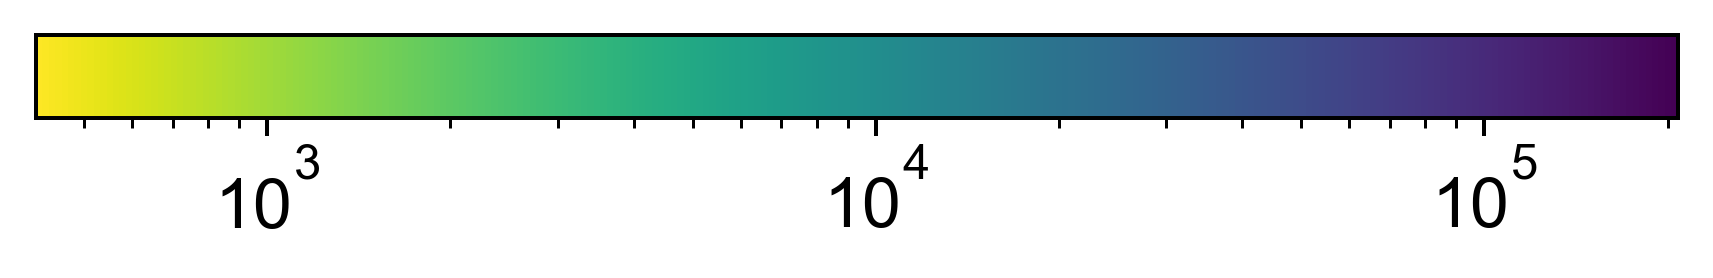

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

# Create data dictionary
data = {
    'adult': {
        'ileum': 25663,
        'sigmoid_colon': 7047,
        'caecum': 5235,
        'transverse_colon': 3975,
        'ascending_colon': 2418,
        'appendix': 2325,
        'descending_colon': 897,
        'duodenum': 669,
        'jejunum': 630,
        'rectum': 417
    },
    'fetal': {
        'duodenum': 207781,
        'ileum': 82680,
        'colon': 27289
    },
    'cell_culture': {
        'ileum': 11748,
        'duodenum': 10558
    }
}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 2))

# Create colormap
vmin = 417  # minimum value
vmax = 207781  # maximum value
norm = LogNorm(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis_r  # Using viridis colormap

# Create colorbar
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                 ax=ax,
                 orientation='horizontal')

# Remove the dummy image
ax.remove()

# Function to get hex color for a value
def get_color_for_value(value):
    normalized_value = norm(value)
    rgba = cmap(normalized_value)
    return mcolors.rgb2hex(rgba)

# Print color codes for each data point
print("\nColor codes for each region:")
print("\nAdult samples:")
for region, value in data['adult'].items():
    color = get_color_for_value(value)
    print(f"{region}: {value} cells -> {color}")

print("\nFetal samples:")
for region, value in data['fetal'].items():
    color = get_color_for_value(value)
    print(f"{region}: {value} cells -> {color}")

print("\nCell culture samples:")
for region, value in data['cell_culture'].items():
    color = get_color_for_value(value)
    print(f"{region}: {value} cells -> {color}")
plt.savefig('figures/colormap_cells_per_region.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 1B

In [86]:
adata.obs['age_group'].value_counts()   

age_group
Unknown               32535
adult & adolescent    16741
Name: count, dtype: int64

In [11]:
adata.obs['age_group'].value_counts()

age_group
second trimester      169491
first trimester       148222
adult & adolescent     49276
cell culture model     22305
Name: count, dtype: int64

In [17]:
adata = adata[~((adata.obs['age_group'] == 'cell culture model') & 
                (~adata.obs['C_scANVI'].isin(['Epithelial', 'Mesenchymal'])))]

In [10]:
mapping = {
    'adult': 'adult & adolescent',
    'child stage': 'adult & adolescent',
    'second trimester': 'second trimester',
    'first trimester': 'first trimester',
    'cell culture model': 'cell culture model'
}

adata.obs['age_group'] = adata.obs['age_group'].map(mapping)

In [12]:
adata.obs['C_scANVI'].value_counts()

C_scANVI
Mesenchymal     185130
Epithelial      110128
Neuronal         21551
T cells          20570
Myeloid          19561
Endothelial      12556
B cells          11110
Plasma cells      8688
Name: count, dtype: int64

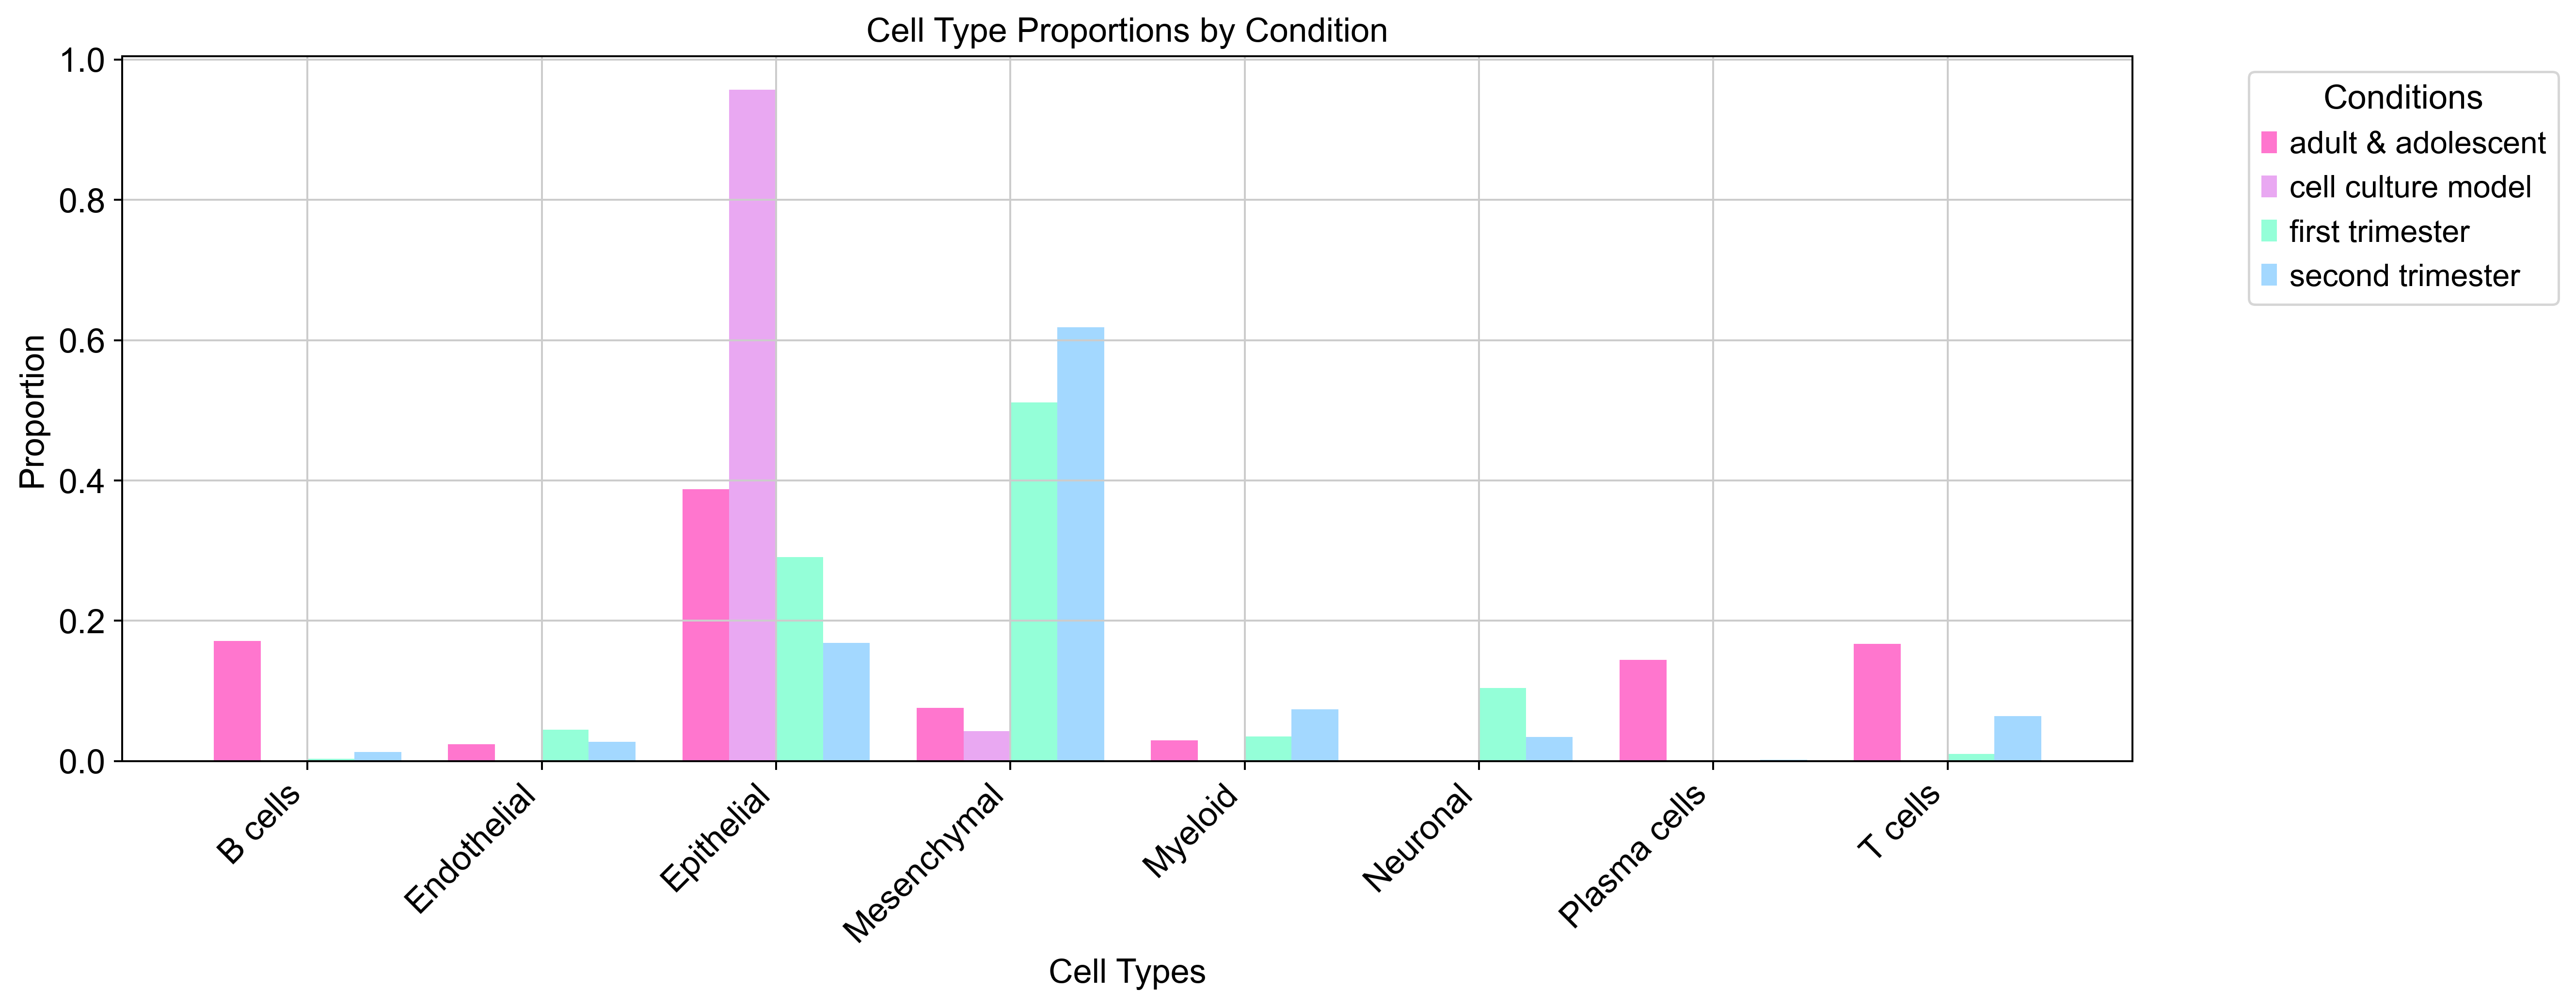

In [ ]:
# Calculate proportions
proportions = pd.crosstab(adata.obs['C_scANVI'], adata.obs['age_group'], normalize='columns')

# Set up the plot
plt.figure(figsize=(15, 6))

# Set the width of each bar and positions of the bars
width = 0.2
x = np.arange(len(proportions.index))

# Create bars for each condition
colors = ['#FF76CE',  # bright pink
                '#E9A8F2',  # light lavender
                '#94FFD8',  # mint green
                '#A3D8FF',  # light sky blue
                '#FFA27F',  # light coral
                '#982B1C',  # bricks color
                '#43766C',  #dark teal
                #'#759EB8',  #steel blue
                '#824670',  # deep purple
                '#ff4a46'] 
for i, (condition, color) in enumerate(zip(proportions.columns, colors)):
    plt.bar(x + i*width, proportions[condition], width, label=condition, color=color)

# Customize the plot
plt.xlabel('Cell Types')
plt.ylabel('Proportion')
plt.title('Cell Type Proportions by Condition')

# Set x-axis labels
plt.xticks(x + width*1.5, proportions.index, rotation=45, ha='right')

# Add legend
plt.legend(title='Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
#plt.savefig('cell_proportions.png', dpi=300, bbox_inches='tight')
#plt.savefig('cell_proportions.svg', bbox_inches='tight', format='svg')

# Show the plot
plt.show()

In [ ]:
# Define bar properties
bar_height = 0.2  # Controls the thickness of each bar
                 # and spacing between groups

def create_horizontal_bars(ax, data, colors, height=bar_height):
    y = np.arange(len(data.index))
    for i, (condition, color) in enumerate(zip(data.columns, colors)):
        ax.barh(y + i*height, data[condition], height, label=condition, color=color)
    return y

# Calculate proportions
proportions = pd.crosstab(adata.obs['C_scANVI'], adata.obs['age_group'], normalize='columns')

# Color scheme
colors = ['#FF76CE',  # bright pink
                '#E9A8F2',  # light lavender
                '#94FFD8',  # mint green
                '#A3D8FF',  # light sky blue
                '#FFA27F',  # light coral
                '#982B1C',  # bricks color
                '#43766C',  #dark teal
                ]  # pink, purple, light green, light blue

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

# Separate large and small proportions
threshold = 0.1  # Adjust this threshold based on your data
max_vals = proportions.max(axis=1)
large_props = proportions[max_vals >= threshold]
small_props = proportions[max_vals < threshold]

# Plot large proportions in main axis
y = create_horizontal_bars(ax, large_props, colors)
ax.set_yticks(y + bar_height*1.5)
ax.set_yticklabels(large_props.index, ha='right')
ax.set_xlabel('Proportion')
ax.set_title('Cell Type Proportions by Condition')

# Add grid lines
ax.grid(True, axis='x', alpha=0.3)

# Create inset axes for small proportions
# Adjust these values to position the inset where you want it
ax_inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])

# Plot small proportions in inset
y_small = create_horizontal_bars(ax_inset, small_props, colors)
ax_inset.set_yticks(y_small + bar_height*1.5)
ax_inset.set_yticklabels(small_props.index, ha='right')
ax_inset.set_title('Small Populations')
ax_inset.grid(True, axis='x', alpha=0.3)

# Add legend outside the plot
ax.legend(title='Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('figures/cell_type_proportions.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
bar_height = 0.2  # Controls the thickness of each bar and spacing between groups

def create_horizontal_bars(ax, data, colors, height=bar_height):
    y = np.arange(len(data.index))
    for i, (condition, color) in enumerate(zip(data.columns, colors)):
        ax.barh(y + i*height, data[condition], height, label=condition, color=color)
    return y

# Calculate cell counts from AnnData object
counts = pd.crosstab(adata.obs['C_scANVI'], adata.obs['age_group'])

# Print the first few rows to verify the data
print("First few rows of the counts table:")
print(counts.head())

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

# Color scheme
colors = ['#FF76CE',  # bright pink
                '#E9A8F2',  # light lavender
                '#94FFD8',  # mint green
                '#A3D8FF',  # light sky blue
                '#FFA27F',  # light coral
                '#982B1C',  # bricks color
                '#43766C',  #dark teal
                ]

# Separate large and small counts
threshold = np.median(counts.max(axis=1))  # Adjust threshold based on counts
print(f"\nThreshold for separating large and small populations: {threshold}")
max_vals = counts.max(axis=1)
large_counts = counts[max_vals >= threshold]
small_counts = counts[max_vals < threshold]

print(f"\nNumber of large populations: {len(large_counts)}")
print(f"Number of small populations: {len(small_counts)}")

# Plot large counts in main axis
y = create_horizontal_bars(ax, large_counts, colors)
ax.set_yticks(y + bar_height*1.5)
ax.set_yticklabels(large_counts.index, ha='right')
ax.set_xlabel('Number of cells')
ax.set_title('Cell Type Counts by Condition')

# Add grid lines
ax.grid(True, axis='x', alpha=0.3)

# Create inset axes for small populations
ax_inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])

# Plot small counts in inset
y_small = create_horizontal_bars(ax_inset, small_counts, colors)
ax_inset.set_yticks(y_small + bar_height*1.5)
ax_inset.set_yticklabels(small_counts.index, ha='right')
ax_inset.grid(True, axis='x', alpha=0.3)

# Add legend outside the plot
ax.legend(title='Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('figures/cell_type_proportions_cell_number.png', dpi=300, bbox_inches='tight')

plt.show()

## Figure 1C

In [37]:
def calculate_expression_stats(adata, genes, groupby='age_group', cell_type_col='cell_type'):
    """Calculate percentage of expressing cells and mean expression for each group."""
    results = []
    
    # Ensure we're working with dense array
    if scipy.sparse.issparse(adata.X):
        expr_matrix = adata.X.toarray()
    else:
        expr_matrix = adata.X
    
    for group in adata.obs[groupby].unique():
        for cell_type in ['Epithelial', 'Mesenchymal']:
            mask = (adata.obs[groupby] == group) & (adata.obs[cell_type_col] == cell_type)
            if np.any(mask):  # Check if we have any cells in this group
                for gene in genes:
                    if gene in adata.var_names:
                        # Get gene index
                        gene_idx = adata.var_names.get_loc(gene)
                        
                        # Get expression values for this gene
                        expr = expr_matrix[mask, gene_idx]
                        
                        # Calculate percentage of expressing cells (> 0)
                        pct = np.mean(expr > 0) * 100
                        
                        # Calculate mean expression in expressing cells
                        mean_expr = np.mean(expr[expr > 0]) if np.any(expr > 0) else 0
                        
                        results.append({
                            'group': group,
                            'cell_type': cell_type,
                            'gene': gene,
                            'pct_expressed': pct,
                            'mean_expression': mean_expr
                        })
    
    return pd.DataFrame(results)

# Assuming we have genes grouped by categories
gene_categories = {
    'Regional markers': ['LHX2', 'EN1', 'GBX2'],
    'NE markers': ['POU5F1', 'CLDN6', 'EPCAM'],
    'RG markers': ['VIM', 'NES', 'CDH2', 'FABP7']
}

# Flatten gene list
all_genes = [gene for genes in gene_categories.values() for gene in genes]

# Calculate statistics
stats_df = calculate_expression_stats(adata, all_genes)

# Create the plot with explicit axes
fig = plt.figure(figsize=(15, 8))
gs = plt.GridSpec(1, 20)
ax = fig.add_subplot(gs[:, :18])  # Main plot
cax = fig.add_subplot(gs[:, 19])  # Colorbar axis

# Set up the grid for the plot
groups = adata.obs['age_group'].unique()
cell_types = ['Epithelial', 'Mesenchymal']
genes = all_genes

# Create meshgrid for coordinates
group_coords = np.arange(len(groups))
gene_coords = np.arange(len(genes))

# Plot dots
for i, group in enumerate(groups):
    for j, cell_type in enumerate(cell_types):
        for k, gene in enumerate(genes):
            data = stats_df[
                (stats_df['group'] == group) & 
                (stats_df['cell_type'] == cell_type) & 
                (stats_df['gene'] == gene)
            ]
            
            if not data.empty:
                size = data['pct_expressed'].iloc[0]
                color = data['mean_expression'].iloc[0]
                
                plt.scatter(
                    k, 
                    i*2 + j,
                    s=size*5,  # Adjust multiplier for dot size
                    c=[color],
                    cmap='Reds',
                    vmin=0,
                    vmax=stats_df['mean_expression'].max(),
                    edgecolor='black',
                    linewidth=0.5
                )

# Customize the plot
plt.yticks(
    np.arange(len(groups)*2),
    [f"{group} {cell_type}" for group in groups for cell_type in cell_types]
)

plt.xticks(
    range(len(all_genes)),
    all_genes,
    rotation=45,
    ha='right'
)

# Add gene category labels
category_positions = []
current_pos = 0
for category, genes in gene_categories.items():
    category_positions.append((current_pos + len(genes)/2, category))
    current_pos += len(genes)
    if current_pos < len(all_genes):
        plt.axvline(x=current_pos-0.5, color='gray', linestyle='--', alpha=0.3)

for pos, category in category_positions:
    plt.text(pos, plt.ylim()[1] + 0.5, category, ha='center', va='bottom')

# Add legend for dot size
sizes = [40, 60, 80, 100]
legend_elements = [plt.scatter([], [], s=s*5, c='gray', label=f'{s}%') for s in sizes]
plt.legend(handles=legend_elements, title='Expressed cells (%)', 
          bbox_to_anchor=(1.15, 1), loc='upper left')

# Add colorbar for expression levels
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(
    vmin=0, vmax=stats_df['mean_expression'].max()))
plt.colorbar(sm, cax=cax, label='Relative expression')

plt.title('Gene Expression Patterns Across Age Groups and Cell Types')
plt.tight_layout()

# Save the plot
#plt.savefig('gene_expression_dotplot.png', dpi=300, bbox_inches='tight')
#plt.savefig('gene_expression_dotplot.svg', format='svg', bbox_inches='tight')

plt.show()

: 

: 

: 